# **3. Perceived Metrics & CNS Fatigue Analysis**

This notebook focuses on subjective athlete feedback as a proxy for **Central Nervous System (CNS) fatigue**. Unlike GPS data, these metrics capture how the athlete's body is *responding* to the prescribed load.

We hypothesize that a persistent state of high exertion coupled with low recovery is a precursor to injury, reflecting a breakdown in physiological adaptation.

### Objectives:
1. **Correlation Analysis:** Investigate the relationship between `perceived exertion` and `perceived recovery`.
2. **Feature Engineering (Lagged Features):** Create sliding windows to capture continuous states of fatigue.
3. **Time-to-Event Analysis:** Determine the typical number of days an athlete remains in a "High Exertion / Low Recovery" state before an injury event occurs.

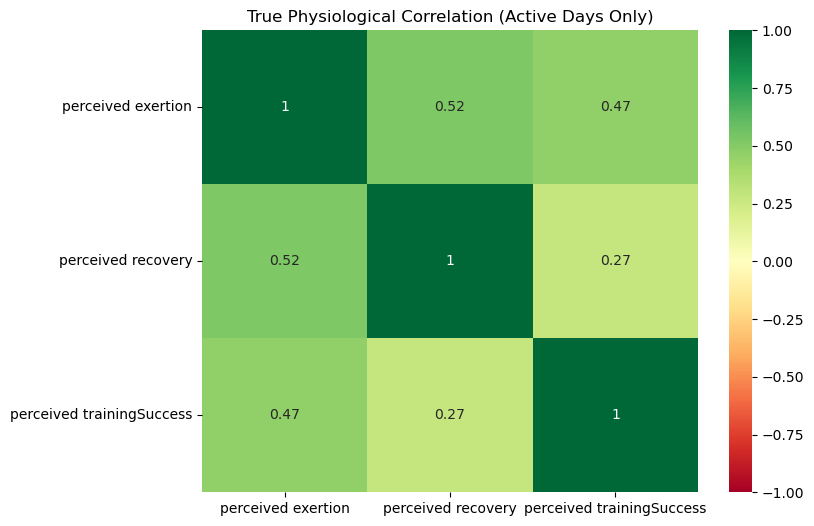

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Data loading and cleaning
# Load the dataset
file_path = '../Dataset/day_approach_maskedID_timeseries.csv'
df = pd.read_csv(file_path)

# Identification of 'Rest Days':
# According to documentation, -0.01 represents a day without a session.
# We create a boolean mask to separate active training from rest.
rest_day_flag = -0.01
active_mask = (df['perceived exertion'] > rest_day_flag) & \
              (df['perceived recovery'] > rest_day_flag) & \
              (df['perceived trainingSuccess'] > rest_day_flag)

# Create a dataframe for active days only to avoid statistical bias from rest days.
df_active = df[active_mask].copy()


# 2. Correlation Analysis: Exertion vs Recovery vs Training Success
# Why: Now that -0.01 is removed, we can see the real physiological link between 
# how hard they train (Exertion) and how well they felt before starting (Recovery).
perceived_cols = ['perceived exertion', 'perceived recovery', 'perceived trainingSuccess']
active_corr = df_active[perceived_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(active_corr, annot=True, cmap='RdYlGn', center=0, vmin=-1, vmax=1)
plt.title('True Physiological Correlation (Active Days Only)')
plt.show()

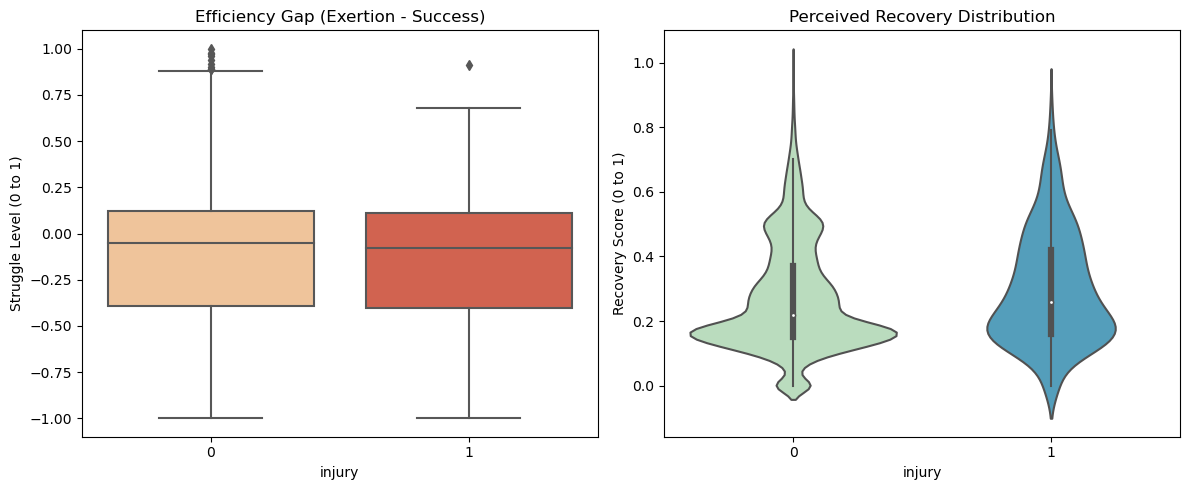

In [3]:
# 3. The "Efficiency Gap": Exertion vs Training Success
# Concept: In Biomedical Engineering, the "Internal Load" is the exertion. 
# The "Output" is the trainingSuccess. 
# If Exertion is high (close to 1.0) but Success is low, the athlete is likely overreaching.

# Feature Engineering: 'Efficiency Gap'
# A positive value means the athlete struggled (High effort, Low success).
# A negative value means the session felt 'easy' for the result obtained.
df_active['efficiency_gap'] = df_active['perceived exertion'] - df_active['perceived trainingSuccess']

# 4. Visualizing the "Efficiency Gap" and Recovery by Injury Status
# We compare the distribution of these 0-1 metrics for Healthy (0) vs Injured (1) days.
plt.figure(figsize=(12, 5))

# Plot A: The Efficiency Gap
plt.subplot(1, 2, 1)
sns.boxplot(data=df_active, x='injury', y='efficiency_gap', palette='OrRd')
plt.title('Efficiency Gap (Exertion - Success)')
plt.ylabel('Struggle Level (0 to 1)')

# Plot B: Recovery levels
plt.subplot(1, 2, 2)
sns.violinplot(data=df_active, x='injury', y='perceived recovery', palette='GnBu')
plt.title('Perceived Recovery Distribution')
plt.ylabel('Recovery Score (0 to 1)')

plt.tight_layout()
plt.show()

In [5]:
# 5. Time to Injury Analysis: Do low recovery days cluster before injuries?
# How many days of "Poor Recovery" (< 0.3) happen before an injury?
low_rec_threshold = 0.3
df_active['low_recovery_flag'] = (df_active['perceived recovery'] < low_rec_threshold).astype(int)

# Grouping by injury to see if 'low recovery' is more frequent in injured athletes
summary_stats = df_active.groupby('injury')[['perceived recovery', 'efficiency_gap', 'perceived trainingSuccess']].mean()

print("BIOMEDICAL SUMMARY (MEAN VALUES 0-1)")
print(summary_stats)

BIOMEDICAL SUMMARY (MEAN VALUES 0-1)
        perceived recovery  efficiency_gap  perceived trainingSuccess
injury                                                               
0                 0.270971       -0.139263                   0.480597
1                 0.299648       -0.150041                   0.556190


### Subjective Metrics: The "Overtraining Trap"
The **Correlation Heatmaps** and the **Biomedical Summary Table** reveal a counter-intuitive and dangerous psychological pattern.

1.  **Correction of Bias:** By filtering out the `-0.01` values (Rest Days), the correlation between `perceived exertion` and `perceived recovery` dropped from **0.71** to **0.52**. This proves that the initial high correlation was a data artifact of rest days, and the "true" physiological correlation is moderate.
2.  **The Success Paradox:** According to the table, injured athletes actually reported **higher perceived trainingSuccess** ($0.55$ vs. $0.48$) and **higher perceived recovery** ($0.30$ vs. $0.27$) than healthy athletes.
3.  **Efficiency Gap:** The `efficiency_gap` is more negative for injured athletes ($-0.15$ vs. $-0.14$). In this context, a more negative gap means their **Success** score is outperforming their **Exertion** score.

### Synthesis: The "False Green Light" Hypothesis

> "The data suggests that athletes are most at risk of injury when they are in a **'high-performance state.'** Because they feel well-rested (higher recovery) and feel the sessions are going well (higher success), they increase their mechanical load (Z5 and Sprinting kilometers). 
>
> Biologically, their **central nervous system (CNS)** feels ready, but their **peripheral tissues** (tendons, ligaments, bones) are accumulating micro-trauma from the increased volume. The injury occurs because the subjective feedback (feeling good) does not warn them about the objective mechanical overload."

---

### Predictive Strategy for your AI Model:
Based on this EDA, your algorithm should not look for "low recovery" as the only warning sign. Instead, it should look for the **combination** of:
1.  **Rising Mechanical Load** (specifically Z5/Sprinting).
2.  **Sustained or Rising Training Success.**
3.  **A positive trend in Perceived Recovery.**

When these three factors peak simultaneously, the athlete is in the **"Danger Zone."**